# Simulations: contamination grid and parameter recovery (CellSweep)

The comparison with the other tools is on `simulation1_small_noise` (`benchmarking.ipynb`, Fig. 2 in
`summary_heatmap.ipynb`). This notebook runs CellSweep alone on simulations derived from it:

1. **Contamination grid.** Ambient level `alpha` ∈ {0.03, 0.10, 0.20} × swapping rate `beta` ∈ {0.01, 0.03, 0.05}.
2. **Profile similarity.** The ambient pool is drawn from a mix of the population and a single cell type, so the
   ambient profile `a` ranges from identical to the global profile `m` to identical to one cell-type profile `p_k`.
   Simulations 5 and 6 (`benchmarking.ipynb`; ambient from the dominant / a rare type) are scored the same way.

All other settings are those of simulation 1. Empty droplets in the simulator draw their ambient load from the same
distribution as cells, which gives them 25% of all counts in simulation 1 and up to 85% at high ambient levels.
In the real datasets used in the paper empty barcodes hold 8–14% of all counts (hgmm 10%, kidney 12%, PBMC 8k 14%,
Janssen nuc2 8%, nuc3 14%), so in sections 1–2 the ambient load of empty droplets is scaled
(`empty_ambient_scale`) to give them 12% of all counts.

For each simulation CellSweep is run at its defaults and compared with the simulated truth:

* **Counts:** sensitivity TP / (TP + FN) and specificity TN / (TN + FP) on rounded counts, as in
  `summary_heatmap.ipynb`, over all cells, for marker genes and for all genes.
* **Noise fraction per cell:** the simulated fraction of a cell's counts that are noise (ambient plus swapped,
  `obs["true_ambient_fraction"]`) against f̂ = (1 − β̂)α̂ + β̂.
* **β:** the simulated swapping rate (fraction of all counts moved to another barcode) against β̂.
* **Profiles:** cosine similarity of `var["ambient_hat"]` with the simulated ambient source profile
  (`var["true_ambient_profile"]`, before the 1% background leakage), and of each row of `uns["p_hat"]` with the
  simulated profile of that type. The global profile `m` is not fitted (it is the normalized total count of each
  gene), so it is not scored.
* **Cell types:** fraction of cells whose final assignment (`obs["z_hat"]`) is the simulated type.

In [1]:
import os
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, display
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse
from scipy.stats import pearsonr, spearmanr

import cellsweep
from cellsweep.simulation import simulate_cells

cellsweep_dir = os.path.dirname(os.path.abspath(""))
data_dir = os.path.join(cellsweep_dir, "notebooks", "data")
config_dir = os.path.join(cellsweep_dir, "notebooks", "config")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "simulations")
os.makedirs(out_dir, exist_ok=True)
overwrite = False  # rerun simulations whose results are already saved
threads = 16

EMPTY_COUNT_SHARE = 0.12  # target share of all counts in empty droplets (real datasets: 0.08-0.14)
SIM_KEYS = ["G", "N", "k", "markers_per_type", "marker_boost", "type_proportions", "empty_prob", "alpha", "beta",
            "expected_cell_size", "noise_logsd_cell", "noise_logsd_empty", "dispersion", "housekeeping_frac",
            "hk_logmean", "hk_logsd"]
with open(os.path.join(config_dir, "simulation1_small_noise.yaml")) as f:
    base_cfg = yaml.safe_load(f)
BASE = {k: base_cfg[k] for k in SIM_KEYS}
CELLSWEEP_KW = dict(max_iter=base_cfg["cellsweep_max_iter"], init_beta=base_cfg["cellsweep_init_beta"],
                    init_alpha=base_cfg["cellsweep_init_alpha"])

INK, MUTED, GRID = "#26251f", "#6f6e69", "#e4e3de"
CS_BLUE = "#2a78d6"
BLUES = LinearSegmentedColormap.from_list(
    "palette_blue", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

In [2]:
def empty_ambient_scale(params, share=EMPTY_COUNT_SHARE):
    """Scale for the empty droplets' ambient load so that they hold `share` of all counts (expected values)."""
    size, alpha = params["expected_cell_size"], params["alpha"]
    n_empty, n_cell = params["N"] * params["empty_prob"], params["N"] * (1 - params["empty_prob"])
    cell_counts = n_cell * (size * np.exp(0.4 ** 2 / 2) + alpha * size * np.exp(params["noise_logsd_cell"] ** 2 / 2))
    empty_counts = n_empty * alpha * size * np.exp(params["noise_logsd_empty"] ** 2 / 2)
    return share / (1 - share) * cell_counts / empty_counts


def _rint(X):
    X = sparse.csr_matrix(X, dtype=np.float64)
    X.data = np.rint(X.data)
    X.eliminate_zeros()
    return X


def cosine(u, v):
    u, v = np.asarray(u, float), np.asarray(v, float)
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))


def evaluate(raw, cs):
    """Compare a CellSweep output with the simulated truth. Returns (summary dict, per-type table, per-cell table)."""
    params = raw.uns["simulation_params"]
    cells = ~raw.obs["is_empty"].to_numpy()
    assert (cs.obs_names == raw.obs_names).all() and (cs.var_names == raw.var_names).all()
    tot = np.asarray(raw.X.sum(axis=1)).ravel()

    beta_hat = float(cs.uns["beta_hat"])
    f_hat = (1 - beta_hat) * cs.obs["alpha_hat"].to_numpy()[cells] + beta_hat
    f_true = raw.obs["true_ambient_fraction"].to_numpy()[cells]

    a_true = raw.var["true_ambient_profile"].to_numpy()
    m_true = np.asarray(raw.X.sum(axis=0)).ravel()
    m_true = m_true / m_true.sum()
    names = list(cs.uns["celltype_names"])
    prof = raw.uns["type_profiles"]
    p_cos = [cosine(cs.uns["p_hat"][k], prof[int(n.split("_")[1])]) for k, n in enumerate(names)]
    z_hat = np.array(names)[cs.obs["z_hat"].to_numpy()[cells] - 1]
    z_true = raw.obs["celltype"].astype(str).to_numpy()[cells]

    Yr, Yt, Yp = (_rint(M[cells]) for M in (raw.X, raw.layers["real"], cs.X))
    TP, FP = Yp.minimum(Yt), (Yp - Yt).maximum(0)
    FN = (Yt - Yp).maximum(0)
    TN = (Yr - TP - FP - FN).maximum(0)
    mk = raw.var["is_marker"].to_numpy().astype(bool)
    scores = {}
    for scope, cols in (("marker", mk), ("all", slice(None))):
        tp, fp, fn, tn = (M[:, cols].sum() for M in (TP, FP, FN, TN))
        scores[f"sensitivity_{scope}"] = tp / (tp + fn)
        scores[f"specificity_{scope}"] = tn / (tn + fp)

    summary = dict(
        cells=int(cells.sum()), empty_count_share=tot[~cells].sum() / tot.sum(),
        beta_true=float(params["beta"]), beta_hat=beta_hat,
        noise_true_mean=f_true.mean(), noise_hat_mean=f_hat.mean(),
        noise_pearson=pearsonr(f_true, f_hat)[0], noise_spearman=spearmanr(f_true, f_hat)[0],
        noise_median_abs_error=float(np.median(np.abs(f_hat - f_true))),
        frac_alpha_zero=float(np.mean(cs.obs["alpha_hat"].to_numpy()[cells] < 1e-3)),
        cos_a_m_true=cosine(a_true, m_true), cos_a_p_true_max=max(cosine(a_true, p) for p in prof),
        cos_ambient=cosine(cs.var["ambient_hat"], a_true),
        cos_p_median=float(np.median(p_cos)), cos_p_min=float(np.min(p_cos)),
        celltype_accuracy=float((z_hat == z_true).mean()), **scores)
    per_type = pd.DataFrame(dict(celltype=z_true, noise_true=f_true, noise_hat=f_hat)).groupby("celltype").agg(
        cells=("noise_true", "size"), noise_true=("noise_true", "mean"), noise_hat=("noise_hat", "mean")).reset_index()
    per_type["p_cos"] = per_type["celltype"].map(dict(zip(names, p_cos)))
    per_cell = pd.DataFrame(dict(noise_true=f_true, noise_hat=f_hat))
    return summary, per_type, per_cell


def run_grid(name, settings, tag_cols, **cs_kw):
    """Simulate and denoise every setting (resumable); returns the summary, per-type and per-cell tables.
    `cs_kw` overrides CellSweep settings (e.g. to remove the global term)."""
    paths = {k: os.path.join(out_dir, f"{name}_{k}.csv") for k in ("summary", "per_type", "per_cell")}
    done = pd.read_csv(paths["summary"]) if os.path.exists(paths["summary"]) and not overwrite else None
    tables = {k: [pd.read_csv(p)] if done is not None else [] for k, p in paths.items()}
    for tag, params in settings.items():
        if done is not None and tag in set(done["setting"]):
            continue
        raw = simulate_cells(**params, rng_seed=42)
        cs = cellsweep.denoise_count_matrix(raw.copy(), threads=threads, quiet=True, **{**CELLSWEEP_KW, **cs_kw})
        summary, per_type, per_cell = evaluate(raw, cs)
        cols = {"setting": tag, **{c: params.get(c) for c in tag_cols}}
        tables["summary"].append(pd.DataFrame([{**cols, **summary}]))
        tables["per_type"].append(per_type.assign(**cols))
        tables["per_cell"].append(per_cell.assign(setting=tag))
        for k, p in paths.items():
            pd.concat(tables[k], ignore_index=True).to_csv(p, index=False)
        print(f"{tag}: specificity (markers) {summary['specificity_marker']:.3f}, "
              f"empty count share {summary['empty_count_share']:.3f}", flush=True)
    return tuple(pd.concat(tables[k], ignore_index=True) for k in ("summary", "per_type", "per_cell"))

## 1. Contamination grid

Ambient level `alpha` (the median ambient load of a cell as a fraction of its expected size) × swapping rate `beta`,
in two settings: the ambient pool drawn from the whole population (so the ambient profile `a` and the global profile
`m` are nearly identical), and drawn half from the population and half from the rarest cell type (so `a` differs from
`m`, cosine ≈ 0.80, as at 50% in section 2).

In [3]:
GRID_ALPHA = [0.03, 0.10, 0.20]
GRID_BETA = [0.01, 0.03, 0.05]
grid_settings = {}
for al in GRID_ALPHA:
    for be in GRID_BETA:
        p = {**BASE, "alpha": al, "beta": be}
        p["empty_ambient_scale"] = empty_ambient_scale(p)
        grid_settings[f"alpha{al:.2f}_beta{be:.2f}"] = p
grid, grid_types, grid_cells = run_grid("grid", grid_settings, ["alpha", "beta", "empty_ambient_scale"])

# second grid: ambient drawn half from the population and half from the rarest type (a differs from m)
grid_props = np.random.default_rng(42).dirichlet(np.ones(BASE["k"]))   # simulation 1's proportions (the simulator's first draw)
grid_rare = int(np.argmin(grid_props))
distinct_weights = (0.5 * grid_props + 0.5 * np.eye(BASE["k"])[grid_rare]).tolist()
distinct_settings = {}
for al in GRID_ALPHA:
    for be in GRID_BETA:
        p = {**BASE, "type_proportions": grid_props.tolist(), "alpha": al, "beta": be,
             "ambient_source_weights": distinct_weights}
        p["empty_ambient_scale"] = empty_ambient_scale(p)
        distinct_settings[f"alpha{al:.2f}_beta{be:.2f}"] = p
grid_distinct, grid_distinct_types, grid_distinct_cells = run_grid(
    "grid_distinct", distinct_settings, ["alpha", "beta", "empty_ambient_scale"])
pd.set_option("display.width", 250)
show = ["empty_count_share", "noise_true_mean", "noise_hat_mean", "noise_pearson", "beta_true", "beta_hat",
        "frac_alpha_zero", "cos_ambient", "cos_p_min", "celltype_accuracy",
        "sensitivity_marker", "specificity_marker", "sensitivity_all", "specificity_all"]
for name, g in (("ambient from the population (a ≈ m)", grid), ("ambient half from the rarest type (a ≠ m)", grid_distinct)):
    print(f"\n{name}")
    print(g.set_index("setting")[["cos_a_m_true"] + show].T.round(3).to_string())

alpha0.03_beta0.01: specificity (markers) 0.918, empty count share 0.119


alpha0.03_beta0.03: specificity (markers) 0.911, empty count share 0.119


alpha0.03_beta0.05: specificity (markers) 0.913, empty count share 0.119


alpha0.10_beta0.01: specificity (markers) 0.939, empty count share 0.119


alpha0.10_beta0.03: specificity (markers) 0.937, empty count share 0.119


alpha0.10_beta0.05: specificity (markers) 0.937, empty count share 0.119


alpha0.20_beta0.01: specificity (markers) 0.954, empty count share 0.118


alpha0.20_beta0.03: specificity (markers) 0.953, empty count share 0.118


alpha0.20_beta0.05: specificity (markers) 0.952, empty count share 0.118



ambient from the population (a ≈ m)
setting             alpha0.03_beta0.01  alpha0.03_beta0.03  alpha0.03_beta0.05  alpha0.10_beta0.01  alpha0.10_beta0.03  alpha0.10_beta0.05  alpha0.20_beta0.01  alpha0.20_beta0.03  alpha0.20_beta0.05
cos_a_m_true                     1.000               1.000               1.000               1.000               1.000               1.000               1.000               1.000               1.000
empty_count_share                0.118               0.118               0.118               0.118               0.118               0.118               0.119               0.119               0.119
noise_true_mean                  0.045               0.063               0.081               0.114               0.132               0.148               0.193               0.209               0.224
noise_hat_mean                   0.045               0.064               0.082               0.116               0.133               0.150               0.195         

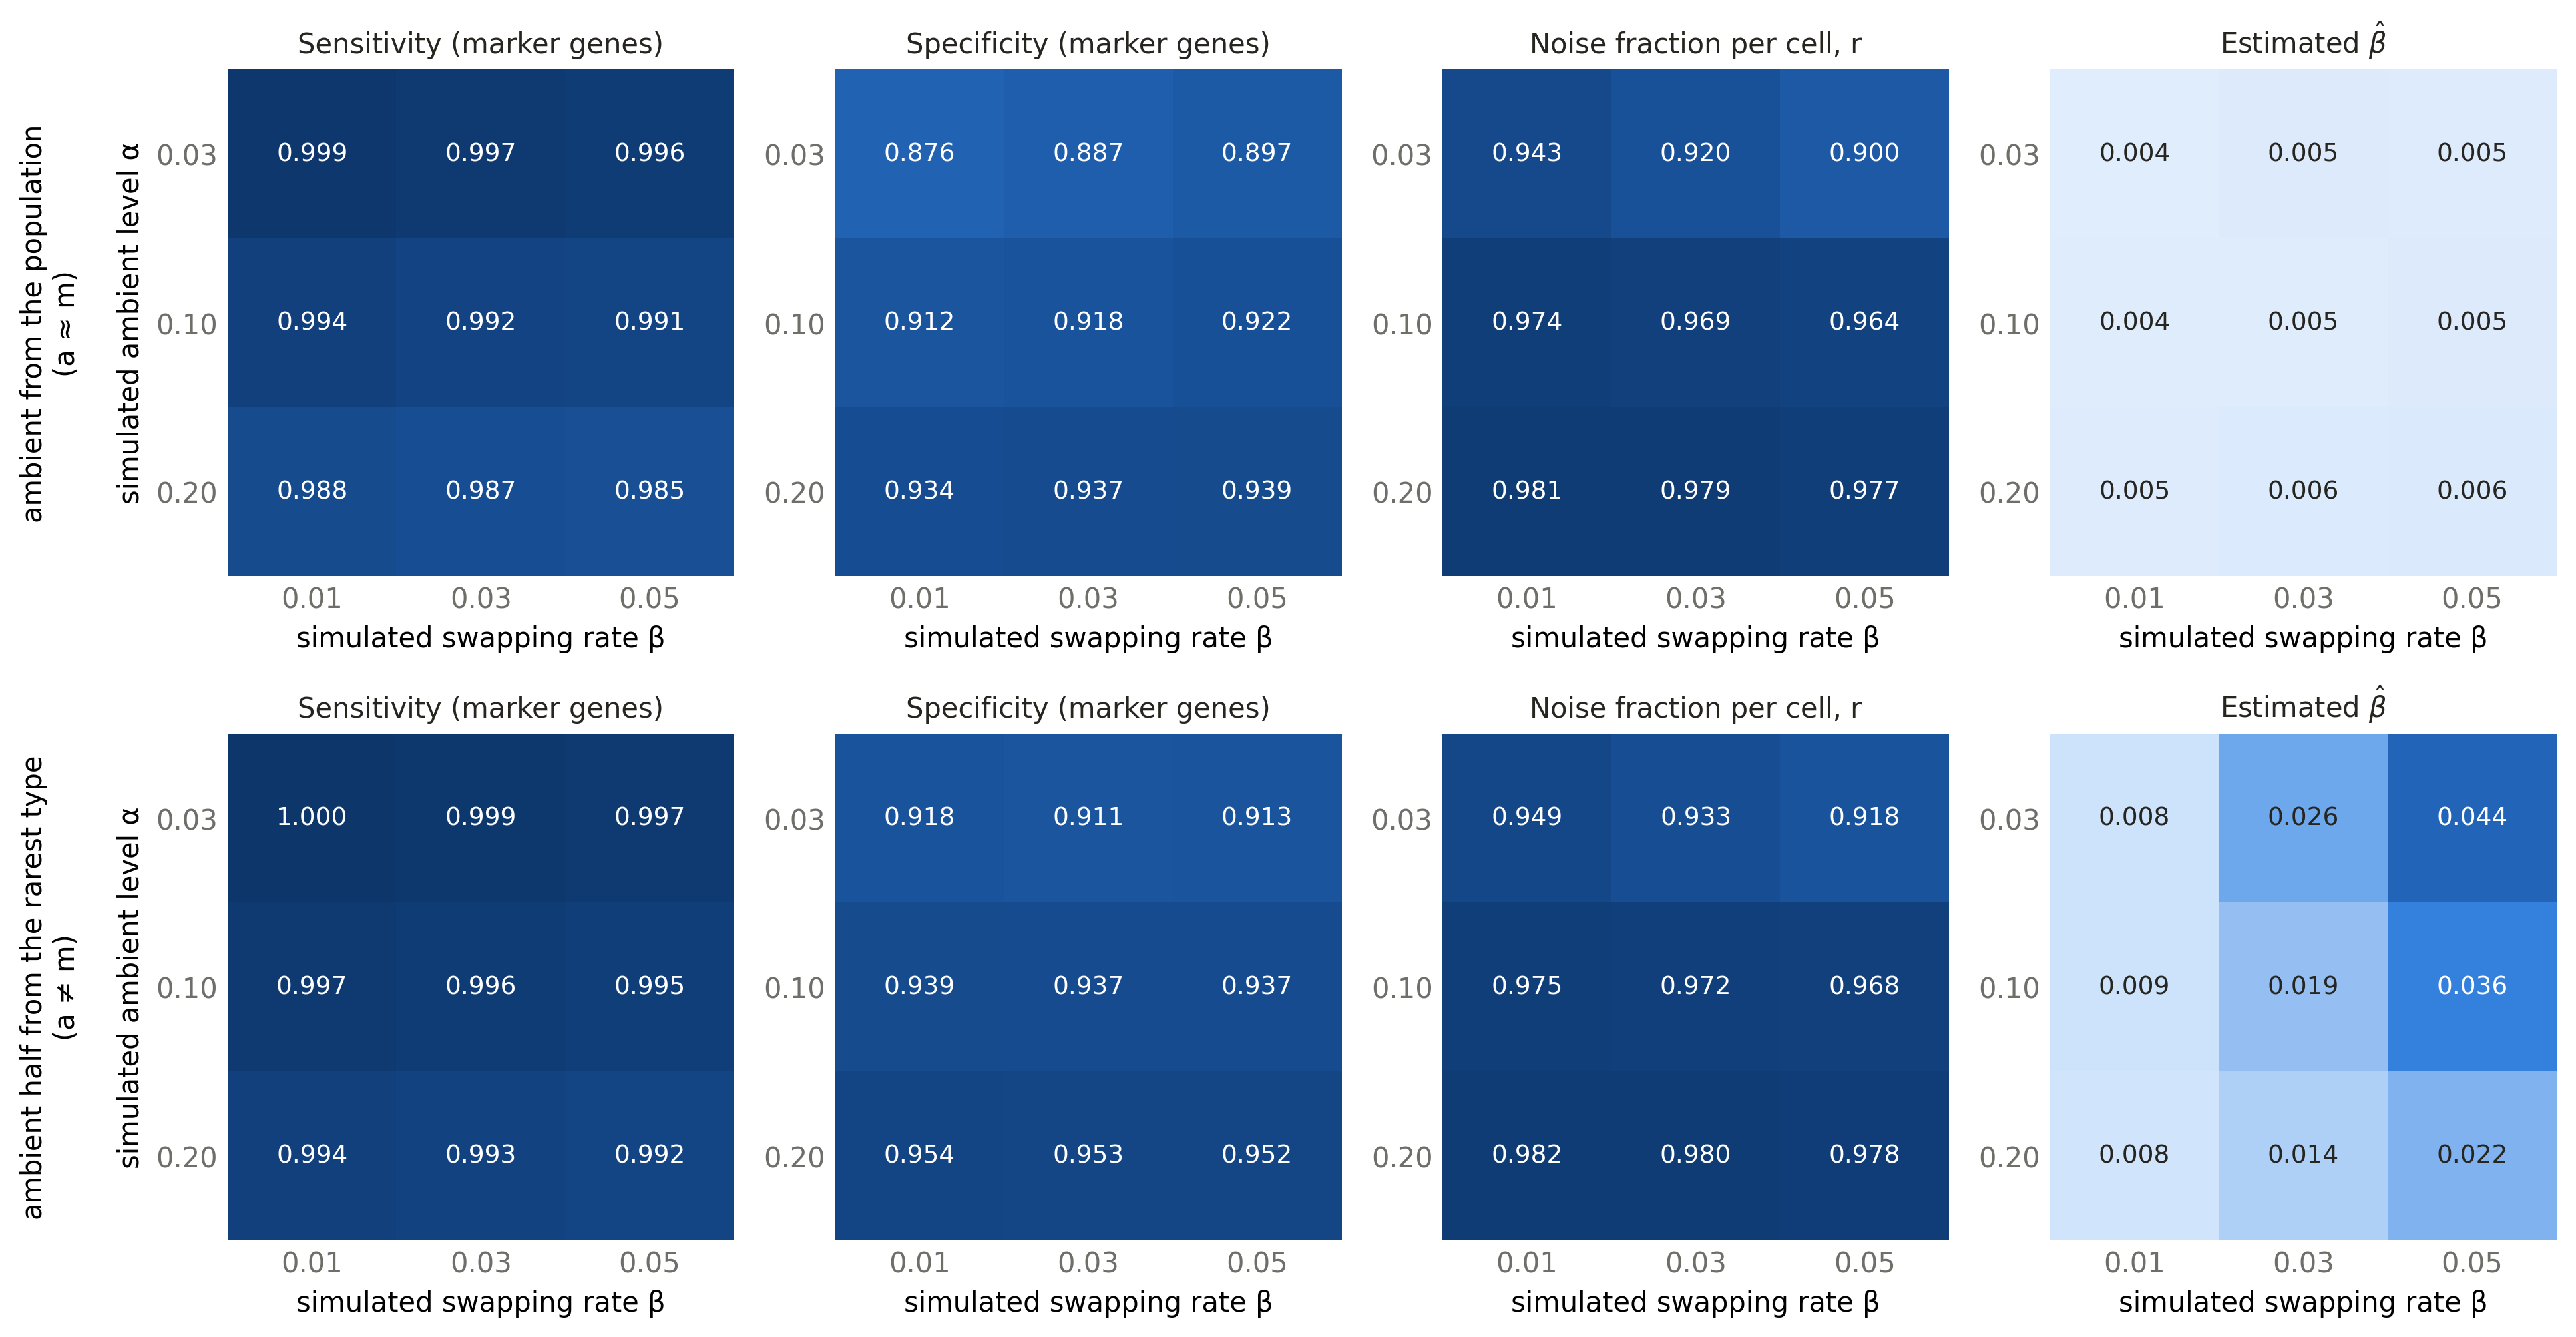

In [4]:
def heat(ax, values, title, fmt="{:.3f}", vmin=None, vmax=None):
    im = ax.imshow(values, cmap=BLUES, vmin=vmin, vmax=vmax)
    norm = im.norm
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values[i, j]
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=9,
                    color="white" if norm(v) > 0.55 else INK)
    ax.set_xticks(range(len(GRID_BETA)), [f"{b:.2f}" for b in GRID_BETA])
    ax.set_yticks(range(len(GRID_ALPHA)), [f"{a:.2f}" for a in GRID_ALPHA])
    ax.set_xlabel("simulated swapping rate β")
    ax.set_title(title, fontsize=10, color=INK)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0, colors=MUTED)


def grid_matrix(df, col):
    return df.pivot(index="alpha", columns="beta", values=col).reindex(index=GRID_ALPHA, columns=GRID_BETA).to_numpy()


rows = [(grid, "ambient from the population\n(a ≈ m)"), (grid_distinct, "ambient half from the rarest type\n(a ≠ m)")]
fig, axes = plt.subplots(len(rows), 4, figsize=(13, 3.4 * len(rows)))
for r, (df, label) in enumerate(rows):
    heat(axes[r, 0], grid_matrix(df, "sensitivity_marker"), "Sensitivity (marker genes)", vmin=0.9, vmax=1.0)
    heat(axes[r, 1], grid_matrix(df, "specificity_marker"), "Specificity (marker genes)", vmin=0.5, vmax=1.0)
    heat(axes[r, 2], grid_matrix(df, "noise_pearson"), "Noise fraction per cell, r", vmin=0.5, vmax=1.0)
    heat(axes[r, 3], grid_matrix(df, "beta_hat"), r"Estimated $\hat{\beta}$", vmin=0, vmax=0.06)
    axes[r, 0].set_ylabel(f"{label}\n\nsimulated ambient level α")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(out_dir, f"grid_heatmaps.{ext}"), dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(os.path.join(out_dir, "grid_heatmaps.png"), width=900))

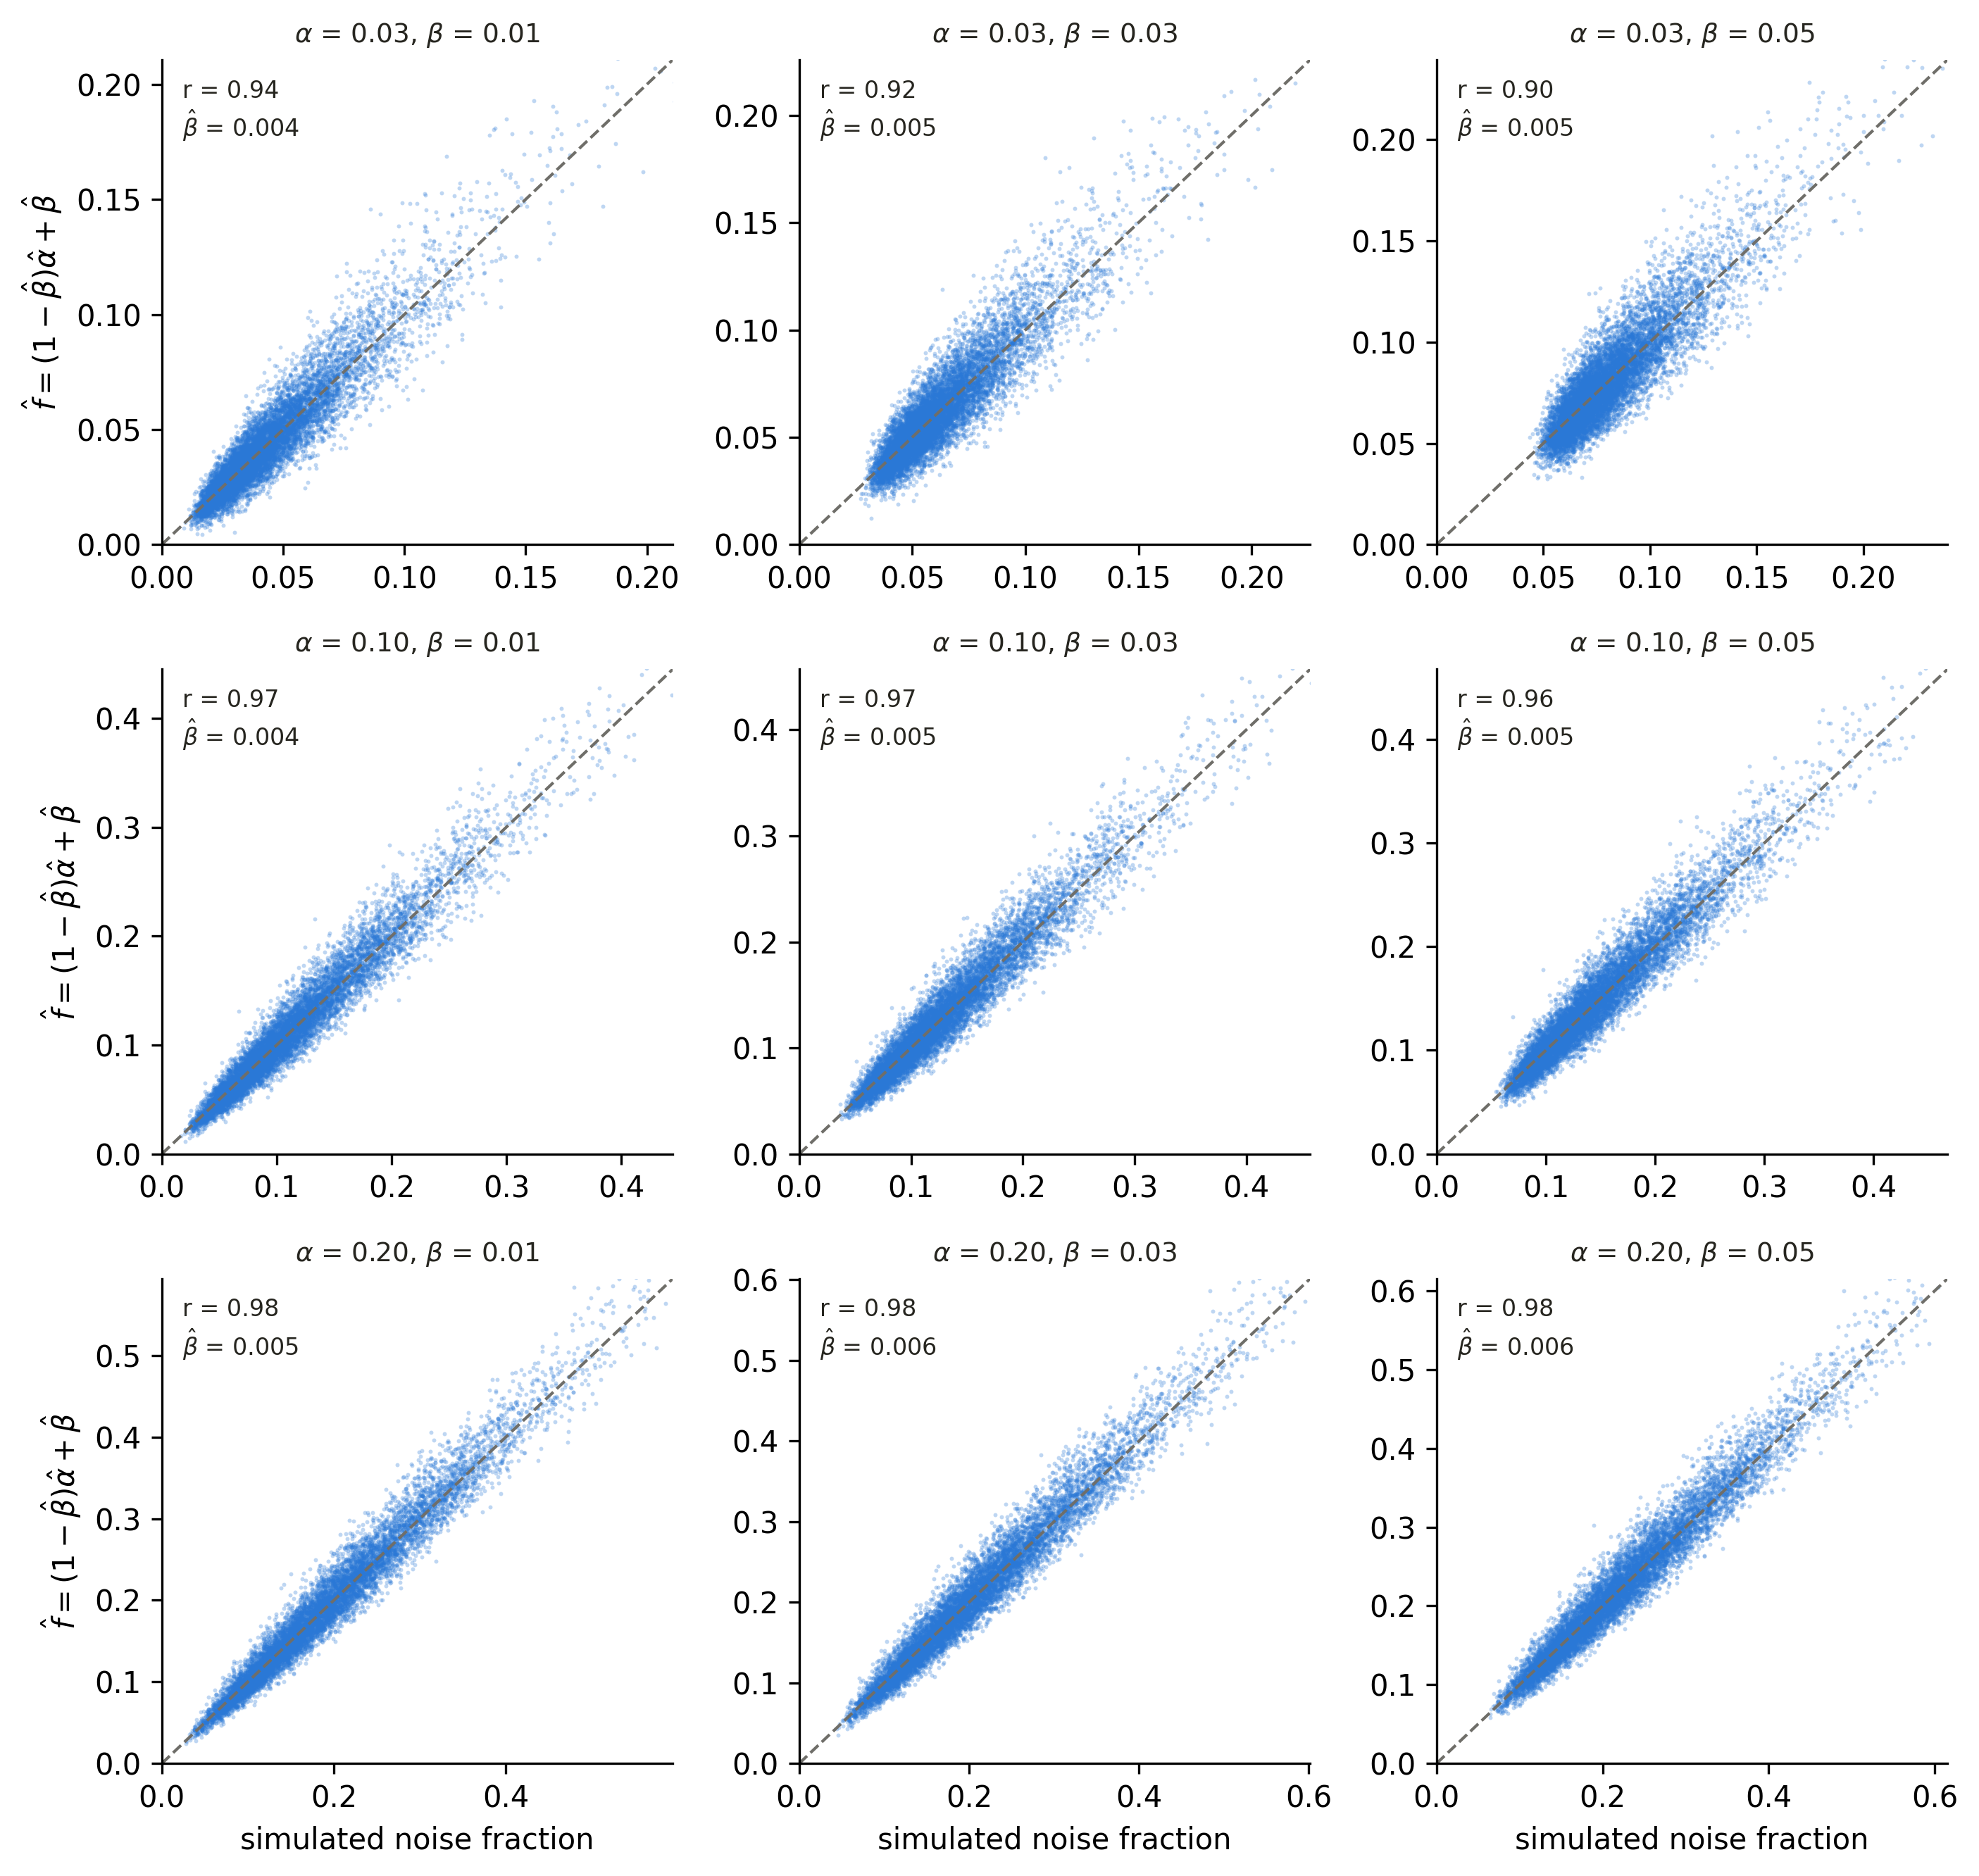

In [5]:
fig, axes = plt.subplots(len(GRID_ALPHA), len(GRID_BETA), figsize=(9.5, 9))
for (i, al), (j, be) in ((x, y) for x in enumerate(GRID_ALPHA) for y in enumerate(GRID_BETA)):
    ax = axes[i, j]
    tag = f"alpha{al:.2f}_beta{be:.2f}"
    d = grid_cells[grid_cells["setting"] == tag]
    r = grid[grid["setting"] == tag].iloc[0]
    lim = max(d["noise_true"].quantile(0.999), d["noise_hat"].quantile(0.999))
    ax.scatter(d["noise_true"], d["noise_hat"], s=2, alpha=0.3, color=CS_BLUE, rasterized=True, linewidths=0)
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_title(rf"$\alpha$ = {al:.2f}, $\beta$ = {be:.2f}", fontsize=9, color=INK)
    ax.text(0.04, 0.96, f"r = {r['noise_pearson']:.2f}\n" + rf"$\hat{{\beta}}$ = {r['beta_hat']:.3f}",
            transform=ax.transAxes, va="top", fontsize=8, color=INK)
    ax.spines[["top", "right"]].set_visible(False)
    if i == len(GRID_ALPHA) - 1:
        ax.set_xlabel("simulated noise fraction")
    if j == 0:
        ax.set_ylabel(r"$\hat{f} = (1-\hat{\beta})\hat{\alpha} + \hat{\beta}$")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(out_dir, f"grid_noise_fraction.{ext}"), dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(os.path.join(out_dir, "grid_noise_fraction.png"), width=750))

## 2. Similarity of the ambient, global and cell-type profiles

The ambient pool is drawn from cell types with weights (1 − t)·(cell-type proportions) + t·(one type), so at t = 0 the
ambient profile equals the global profile and at t = 1 it is the profile of a single type. The source is either the
rarest or the most abundant type. Ambient level 0.10 and swapping rate 0.03 (middle of the grid); cell-type
proportions are those of simulation 1.

In [3]:
SIM_T = [0.0, 0.25, 0.5, 0.75, 1.0]
SIM_ALPHA, SIM_BETA = 0.10, 0.03
props = np.random.default_rng(42).dirichlet(np.ones(BASE["k"]))  # simulation 1's proportions (the simulator's first draw)
sources = {"rare": int(np.argmin(props)), "abundant": int(np.argmax(props))}
print({s: f"Type_{k} ({props[k]:.1%} of cells)" for s, k in sources.items()})
sim_settings = {}
for src, k in sources.items():
    for t in SIM_T:
        if t == 0 and src == "abundant":
            continue  # same as the rare-source t = 0
        w = (1 - t) * props + t * np.eye(BASE["k"])[k]
        p = {**BASE, "type_proportions": props.tolist(), "alpha": SIM_ALPHA, "beta": SIM_BETA,
             "ambient_source_weights": w.tolist()}
        p["empty_ambient_scale"] = empty_ambient_scale(p)
        sim_settings["population" if t == 0 else f"{src}_t{t:.2f}"] = p
similarity, similarity_types, similarity_cells = run_grid("similarity", sim_settings, ["empty_ambient_scale"])
similarity["source"] = similarity["setting"].str.split("_").str[0]
similarity["t"] = [0.0 if s == "population" else float(s.split("_t")[1]) for s in similarity["setting"]]
src_type = {tag: (f"Type_{sources[tag.split('_')[0]]}" if tag != "population" else None) for tag in similarity["setting"]}
st = similarity_types.assign(is_source=[src_type[s] == c for s, c in zip(similarity_types["setting"], similarity_types["celltype"])])
src_rows = st[st["is_source"]].set_index("setting")
other = st[~st["is_source"]].groupby("setting")[["noise_true", "noise_hat", "cells"]].apply(
    lambda d: pd.Series({"other_noise_true": np.average(d["noise_true"], weights=d["cells"]),
                         "other_noise_hat": np.average(d["noise_hat"], weights=d["cells"])}))
similarity = similarity.join(src_rows[["noise_true", "noise_hat"]].add_prefix("source_"), on="setting").join(other, on="setting")
similarity.to_csv(os.path.join(out_dir, "similarity_summary_with_source.csv"), index=False)
show = ["cos_a_m_true", "cos_a_p_true_max", "noise_pearson", "beta_hat", "cos_ambient", "cos_p_min", "celltype_accuracy",
        "source_noise_true", "source_noise_hat", "other_noise_true", "other_noise_hat",
        "sensitivity_marker", "specificity_marker"]
print(similarity.set_index("setting")[show].T.round(3).to_string())

{'rare': 'Type_10 (0.4% of cells)', 'abundant': 'Type_7 (19.8% of cells)'}
setting             population  rare_t0.25  rare_t0.50  rare_t0.75  rare_t1.00  abundant_t0.25  abundant_t0.50  abundant_t0.75  abundant_t1.00
cos_a_m_true             1.000       0.936       0.801       0.698       0.646           0.966           0.900           0.845           0.808
cos_a_p_true_max         0.629       0.710       0.918       0.987       1.000           0.846           0.953           0.992           1.000
noise_pearson            0.969       0.972       0.972       0.973       0.846           0.968           0.962           0.947           0.770
beta_hat                 0.005       0.008       0.019       0.027       0.010           0.006           0.014           0.024           0.010
cos_ambient              1.000       1.000       1.000       1.000       1.000           1.000           1.000           1.000           1.000
cos_p_min                0.991       0.990       0.992       0.993 

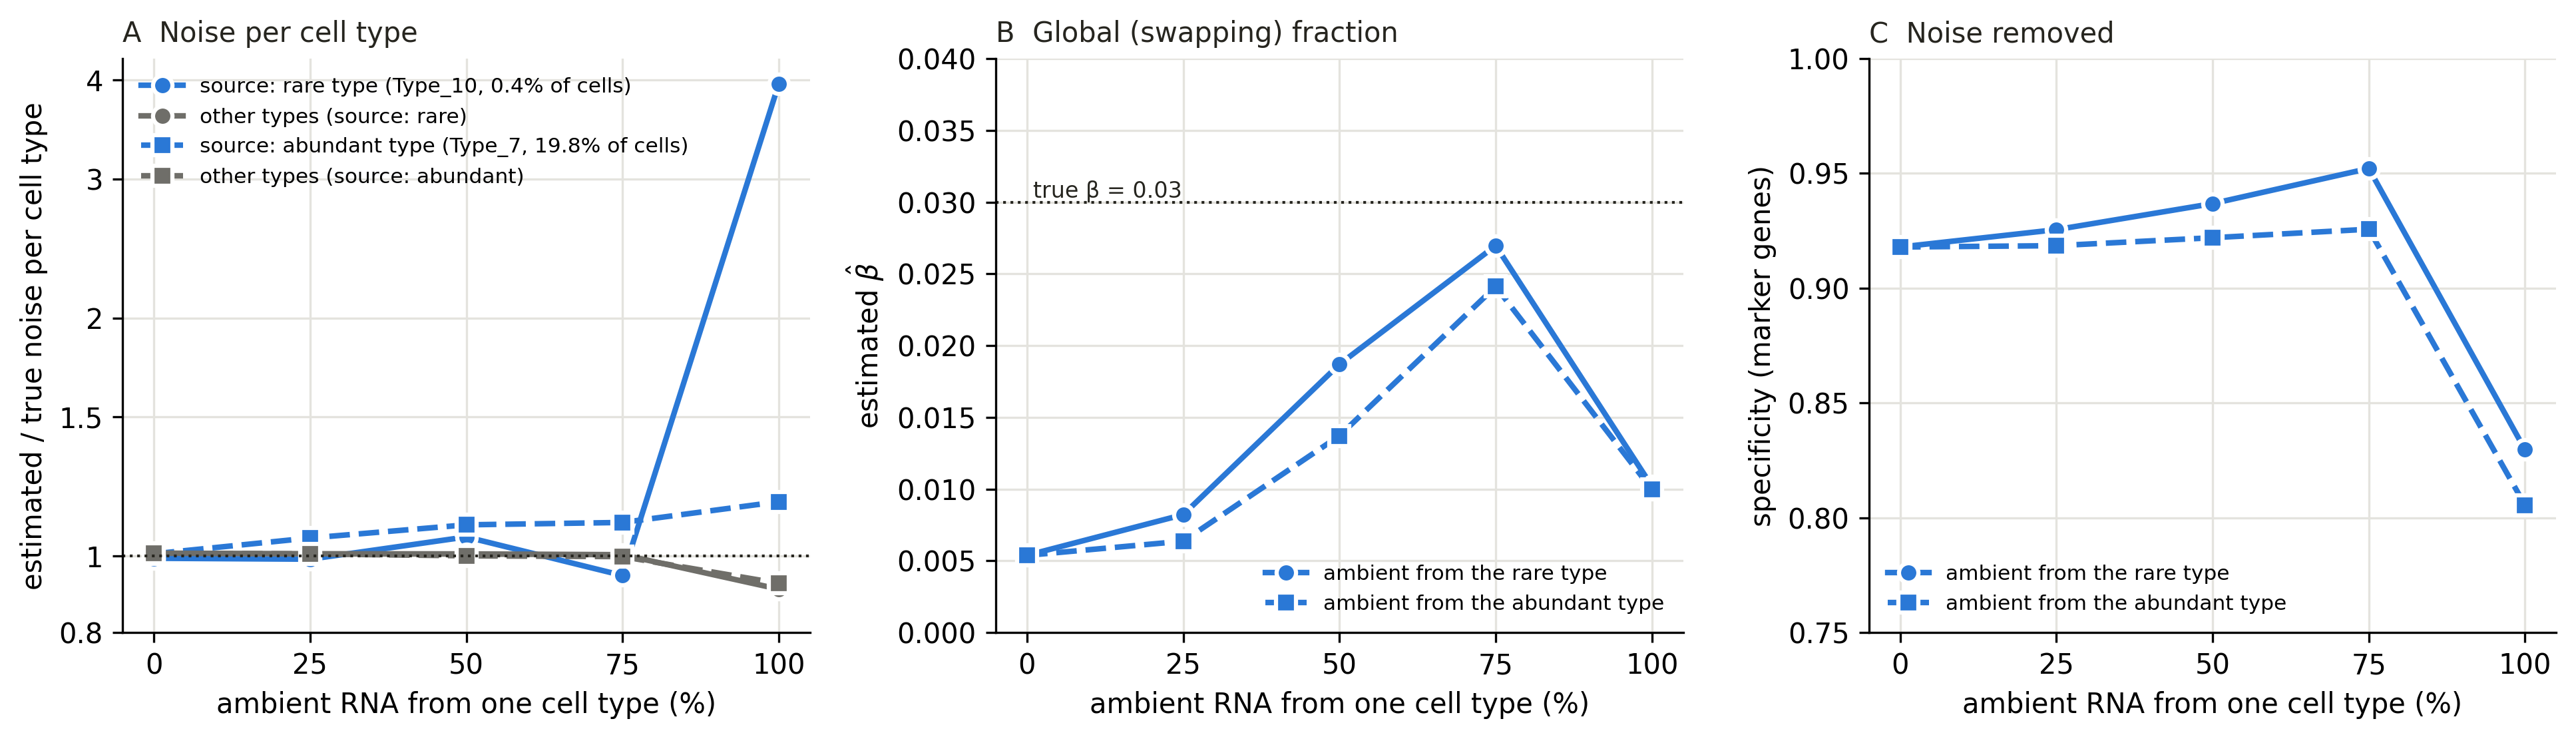

In [4]:
# x: share of the ambient pool drawn from one cell type (t); t = 0 is the population mix, shared by both sources
pop_types = similarity_types[similarity_types["setting"] == "population"].set_index("celltype")
pop_other = similarity.loc[similarity["setting"] == "population", ["other_noise_true", "other_noise_hat"]].iloc[0]
curves = {}
for src, k in sources.items():
    d = similarity[similarity["source"] == src].sort_values("t")
    src0 = pop_types.loc[f"Type_{k}"]
    curves[src] = pd.DataFrame({
        "share": np.r_[0.0, d["t"]] * 100,
        "source_ratio": np.r_[src0["noise_hat"] / src0["noise_true"], d["source_noise_hat"] / d["source_noise_true"]],
        "other_ratio": np.r_[pop_other["other_noise_hat"] / pop_other["other_noise_true"],
                             d["other_noise_hat"] / d["other_noise_true"]],
        "beta_hat": np.r_[similarity.loc[similarity["setting"] == "population", "beta_hat"].iloc[0], d["beta_hat"]],
        "specificity": np.r_[similarity.loc[similarity["setting"] == "population", "specificity_marker"].iloc[0],
                             d["specificity_marker"]]})
style = {"rare": dict(ls="-", marker="o"), "abundant": dict(ls="--", marker="s")}
src_label = {s: f"{s} type (Type_{k}, {props[k]:.1%} of cells)" for s, k in sources.items()}
line = dict(lw=2, ms=7, markeredgecolor="white", markeredgewidth=1.5)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
ax = axes[0]
for src, d in curves.items():
    ax.plot(d["share"], d["source_ratio"], color=CS_BLUE, label=f"source: {src_label[src]}", **style[src], **line)
    ax.plot(d["share"], d["other_ratio"], color=MUTED, label=f"other types (source: {src})", **style[src], **line)
ax.axhline(1, color=INK, lw=1, ls=":")
ax.set_yscale("log")
ax.set_yticks([0.8, 1, 1.5, 2, 3, 4], ["0.8", "1", "1.5", "2", "3", "4"])
ax.minorticks_off()
ax.set_ylabel("estimated / true noise per cell type")
ax.set_title("A  Noise per cell type", loc="left", fontsize=10, color=INK)
ax.legend(frameon=False, fontsize=7.5, loc="upper left")

ax = axes[1]
for src, d in curves.items():
    ax.plot(d["share"], d["beta_hat"], color=CS_BLUE, label=f"ambient from the {src} type", **style[src], **line)
ax.axhline(SIM_BETA, color=INK, lw=1, ls=":")
ax.text(1, SIM_BETA, f"true β = {SIM_BETA:.2f}", va="bottom", fontsize=8, color=INK)
ax.set_ylim(0, 0.04)
ax.set_ylabel(r"estimated $\hat{\beta}$")
ax.set_title("B  Global (swapping) fraction", loc="left", fontsize=10, color=INK)
ax.legend(frameon=False, fontsize=7.5, loc="lower right")

ax = axes[2]
for src, d in curves.items():
    ax.plot(d["share"], d["specificity"], color=CS_BLUE, label=f"ambient from the {src} type", **style[src], **line)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("specificity (marker genes)")
ax.set_title("C  Noise removed", loc="left", fontsize=10, color=INK)
ax.legend(frameon=False, fontsize=7.5, loc="lower left")

for ax in axes:
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel("ambient RNA from one cell type (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(out_dir, f"similarity.{ext}"), dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(os.path.join(out_dir, "similarity.png"), width=900))

## 3. Without the global component

The simulations of section 2 rerun with the global term removed (β fixed at 0: `init_beta=0`, `beta_prior_mode=0`,
`beta_prior_strength=1e6`, as in `parameter_sweep.ipynb`), so the swapped counts (simulated β = 0.03) can only be
attributed to the ambient term or the cell-type profiles. Compared with the full model on the same simulations.

In [4]:
NO_GLOBAL = dict(init_beta=0.0, beta_prior_mode=0.0, beta_prior_strength=1e6)
no_global, no_global_types, _ = run_grid("similarity_no_global", sim_settings, ["empty_ambient_scale"], **NO_GLOBAL)


def with_source_ratios(summary, types):
    """Add t, source, and estimated/true noise for the ambient source type and the other types."""
    d = summary.copy()
    d["source"] = d["setting"].str.split("_").str[0]
    d["t"] = [0.0 if s == "population" else float(s.split("_t")[1]) for s in d["setting"]]
    rows = []
    for tag in d["setting"]:
        ty = types[types["setting"] == tag]
        src = None if tag == "population" else f"Type_{sources[tag.split('_')[0]]}"
        s, o = ty[ty["celltype"] == src], ty[ty["celltype"] != src]
        rows.append(dict(setting=tag,
                         source_ratio=float(s["noise_hat"].iloc[0] / s["noise_true"].iloc[0]) if len(s) else np.nan,
                         other_ratio=float(np.average(o["noise_hat"], weights=o["cells"]) /
                                           np.average(o["noise_true"], weights=o["cells"]))))
    return d.merge(pd.DataFrame(rows), on="setting")


ablation = pd.concat([with_source_ratios(similarity.drop(columns=["source", "t"]), similarity_types).assign(model="with global term"),
                      with_source_ratios(no_global, no_global_types).assign(model="without global term")], ignore_index=True)
ablation.to_csv(os.path.join(out_dir, "similarity_global_ablation.csv"), index=False)
show = ["cos_a_m_true", "beta_hat", "noise_hat_mean", "specificity_marker", "sensitivity_marker", "other_ratio", "source_ratio"]
order = ["population"] + [f"{s}_t{t:.2f}" for s in sources for t in SIM_T[1:]]
for c in show:
    print(f"\n{c}")
    print(ablation.pivot_table(index="model", columns="setting", values=c).reindex(columns=order).round(3).to_string())


cos_a_m_true
setting              population  rare_t0.25  rare_t0.50  rare_t0.75  rare_t1.00  abundant_t0.25  abundant_t0.50  abundant_t0.75  abundant_t1.00
model                                                                                                                                          
with global term            1.0       0.936       0.801       0.698       0.646           0.966             0.9           0.845           0.808
without global term         1.0       0.936       0.801       0.698       0.646           0.966             0.9           0.845           0.808

beta_hat
setting              population  rare_t0.25  rare_t0.50  rare_t0.75  rare_t1.00  abundant_t0.25  abundant_t0.50  abundant_t0.75  abundant_t1.00
model                                                                                                                                          
with global term          0.005       0.008       0.019       0.027        0.01           0.006           0.014 

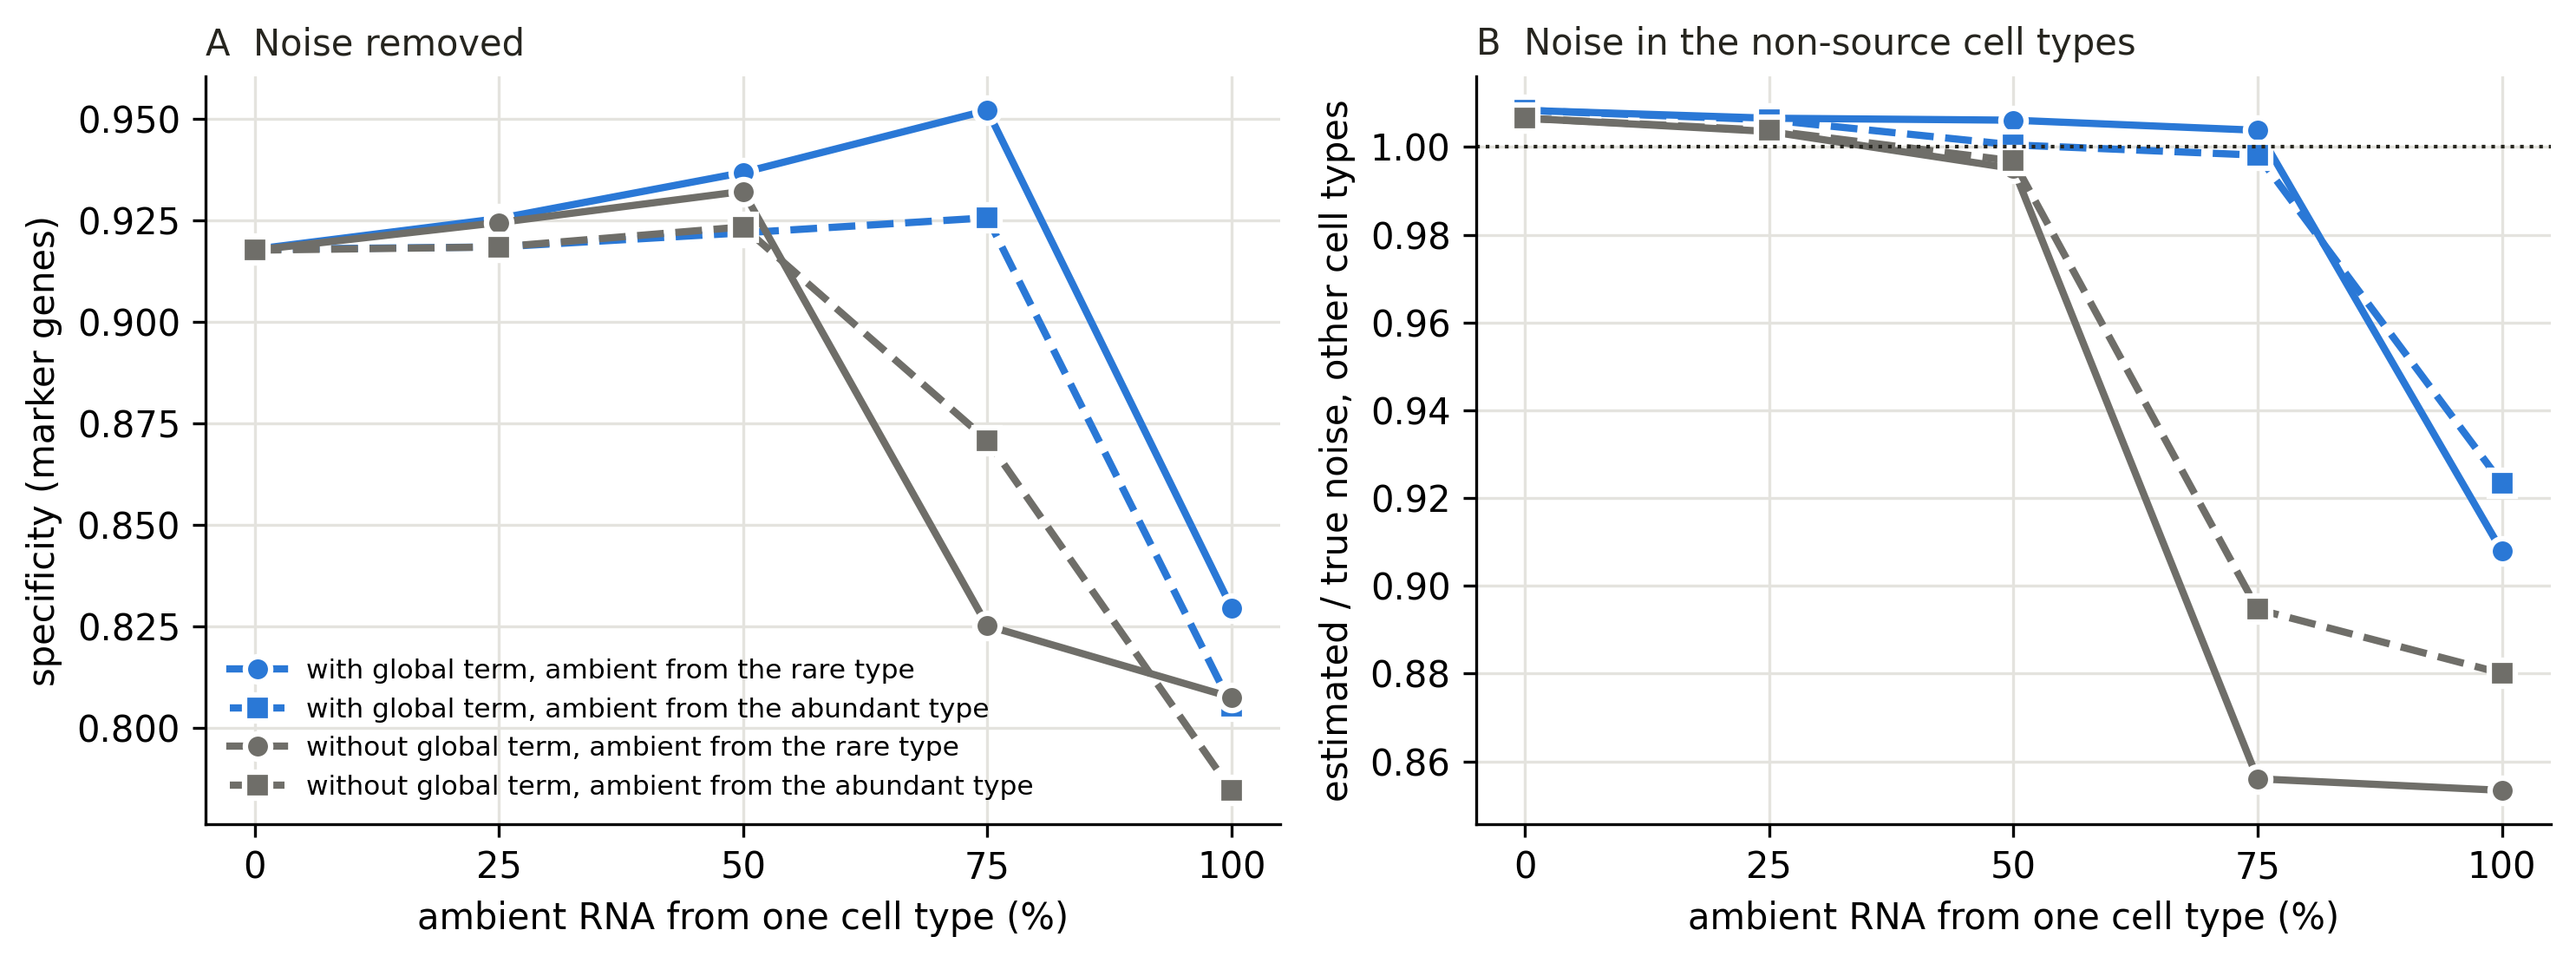

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
colors = {"with global term": CS_BLUE, "without global term": MUTED}
style = {"rare": dict(ls="-", marker="o"), "abundant": dict(ls="--", marker="s")}
line = dict(lw=2, ms=7, markeredgecolor="white", markeredgewidth=1.5)
for model, col in colors.items():
    m = ablation[ablation["model"] == model]
    base = m[m["setting"] == "population"]
    for src in sources:
        d = pd.concat([base, m[m["source"] == src]]).sort_values("t")
        lab = f"{model}, ambient from the {src} type"
        axes[0].plot(d["t"] * 100, d["specificity_marker"], color=col, label=lab, **style[src], **line)
        axes[1].plot(d["t"] * 100, d["other_ratio"], color=col, label=lab, **style[src], **line)
axes[0].set_ylabel("specificity (marker genes)")
axes[0].set_title("A  Noise removed", loc="left", fontsize=10, color=INK)
axes[1].axhline(1, color=INK, lw=1, ls=":")
axes[1].set_ylabel("estimated / true noise, other cell types")
axes[1].set_title("B  Noise in the non-source cell types", loc="left", fontsize=10, color=INK)
axes[0].legend(frameon=False, fontsize=7.5, loc="lower left")
for ax in axes:
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel("ambient RNA from one cell type (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(out_dir, f"similarity_global_ablation.{ext}"), dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(os.path.join(out_dir, "similarity_global_ablation.png"), width=850))

## 4. Simulations 1, 5 and 6

Scored the same way from the `benchmarking.ipynb` outputs (empty droplets not rescaled: 25% of all counts).
Simulation 5: Type_0 is 60% of cells and 95% of the ambient source; simulation 6: Type_11 is 5% of cells and 90% of
the ambient source.

In [8]:
rows, type_rows = [], []
for sim in ["simulation1_small_noise", "simulation5_ambient_dominant_type", "simulation6_ambient_rare_type"]:
    with open(os.path.join(config_dir, f"{sim}.yaml")) as f:
        c = yaml.safe_load(f)
    raw = ad.read_h5ad(os.path.join(data_dir, sim, c["adata_raw_file_name"]))
    cs = ad.read_h5ad(os.path.join(data_dir, sim, c["adata_path_cellsweep_name"]))
    summary, per_type, _ = evaluate(raw, cs)
    rows.append({"simulation": sim, **summary})
    type_rows.append(per_type.assign(simulation=sim))
named = pd.DataFrame(rows)
named_types = pd.concat(type_rows, ignore_index=True)
named.to_csv(os.path.join(out_dir, "named_sims_summary.csv"), index=False)
named_types.to_csv(os.path.join(out_dir, "named_sims_per_type.csv"), index=False)
print(named.set_index("simulation").T.round(4).to_string())
for sim, src in [("simulation5_ambient_dominant_type", "Type_0"), ("simulation6_ambient_rare_type", "Type_11")]:
    d = named_types[named_types["simulation"] == sim]
    s, o = d[d["celltype"] == src].iloc[0], d[d["celltype"] != src]
    print(f"{sim}: source {src} noise {s['noise_true']:.4f} true vs {s['noise_hat']:.4f} estimated; other types "
          f"{np.average(o['noise_true'], weights=o['cells']):.4f} vs {np.average(o['noise_hat'], weights=o['cells']):.4f}")

simulation              simulation1_small_noise  simulation5_ambient_dominant_type  simulation6_ambient_rare_type
cells                                10157.0000                         10155.0000                     10155.0000
empty_count_share                        0.2470                             0.2462                         0.2463
beta_true                                0.0100                             0.0100                         0.0100
beta_hat                                 0.0052                             0.0069                         0.0090
noise_true_mean                          0.0444                             0.0446                         0.0446
noise_hat_mean                           0.0448                             0.0528                         0.0471
noise_pearson                            0.9414                             0.6288                         0.8408
noise_spearman                           0.9230                             0.6081      